## 2D Random Walk
With constant magnitude of displacement for each time step.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
displacement_mag = 1 #fixed the magnitude of discplacement to be constant
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

In [ ]:
#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        #print(r2)
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

In [ ]:
def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1): 
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [ ]:
#particle1 = generate_trajectory(1000, starting_position)
particle2 = generate_trajectory(10, starting_position)
particle3 = generate_trajectory(1000, starting_position)

#print(particle1)
print(particle2)

print(calculate_MSD(2, particle2))
#print(calculate_MSD(10, particle1))
print(calculate_MSD(50, particle3))

In [ ]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

However, closer to actual Brownian motion, the magnitude of displacement need not be constant all the time… Instead it may be a more realistic simulation to choose a magnitude of displacement from a normal distribution for each time step. 

In [ ]:
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    #displacement= np.random.normal(loc=1, scale=2)
    #angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = np.random.normal(loc=0, scale=1)
    y_direction = np.random.normal(loc=0, scale=1)
    #print(x_direction, y_direction)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [ ]:
generate_direction_vector()

In [ ]:
particle1 = generate_trajectory(100, starting_position)
particle1_data = generate_MSD_dataset(10, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(1000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(100000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

In [ ]:
particle1 = generate_trajectory(1000000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
#print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

What happens when we enforce boundaries on how far the particle can actually travel? Will that change the shape of the MSD on time graph? 

In [ ]:
"""
(-5, 5) -------- (5,5)
|
|
|
|
(-5, -5) -------- (-5,5)

"""

def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])
 
def generate_trajectory(time, starting_position, boundary_x, boundary_y):
    trajectory = [np.concatenate((np.array([0]), starting_position))]
    current_position = starting_position.copy()
    current_time = 0
    while current_time < time:
        current_time += 1
        next_step = current_position + generate_direction_vector().copy()
        current_position = rebound_at_boundary(boundary_x, boundary_y, next_step)
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
    return trajectory 

In [ ]:
boundary_x = 1
boundary_y = 1
trajectory1 = generate_trajectory(100, np.array([0,0], dtype=float), boundary_x, boundary_y)
print(trajectory1)

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]


particle1 = generate_trajectory(1000000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 2
boundary_y = 2

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 5
boundary_y = 5

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 10
boundary_y = 10

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


In [ ]:
boundary_x = 100
boundary_y = 100

particle1 = generate_trajectory(100000, np.array([0,0], dtype=float), boundary_x, boundary_y)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )


Clearly, as the boundary of the container increases, the behaviour of the graph tends to what we would expect without boundary in part 1 (boundary of the graph goes to infinity). 
Otherwise, for a small enough container, the MSD plateaus after a certain threshold in time. Why?

In [ ]:
%pip install ipympl

In [2]:
#will attempt to use the langevin model to simulate the motion of the tagged particle. 

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#to generate the random motion of particle
def generate_direction_vector(velocity_background):
    magnitude = velocity_background
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = magnitude*math.cos(angle)
    y_direction = magnitude*math.sin(angle)
    return np.array([x_direction, y_direction])

#initialises a particular arrangement of the background particles for given number of background particles and container size (square)
def initialise_background(number_of_particles, container_length, velocity_background):
    background_initial = []
    for number in range(number_of_particles):
        x_coordinate = np.random.uniform(-container_length, container_length)
        y_coordinate = np.random.uniform(-container_length, container_length)
        background_initial.append([np.array([x_coordinate, y_coordinate]), generate_direction_vector(velocity_background)]) 
    print(background_initial)
    return background_initial


def rebound_at_boundary(boundary_x, boundary_y, particle):
    #rightcorner
    particle_position = particle[0]
    particle_velocity = particle[1]
    magnitude = abs(particle_position)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = particle_position[0]
    y = particle_position[1]

    if boundary_violated[0]:
        new_x_velocity = -1*particle_velocity[0]
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    else:
        new_x_velocity = particle_velocity[0]
        
    if boundary_violated[1]:
        new_y_velocity = -1*particle_velocity[1]
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    else:
        new_y_velocity = particle_velocity[1]
    return [np.array([x,y]), np.array([new_x_velocity, new_y_velocity])]

def update_background_position(current_background, container_length, dt):
    updated_background = []
    for particle in current_background:
        current_position = particle[0]
        hypothetical_position = current_position + particle[1]*dt #add displacement vector for the particular particle
        actual_particle = rebound_at_boundary(container_length, container_length, [hypothetical_position, particle[1]])
        updated_background.append(actual_particle)
        
    return updated_background
    

In [3]:
initialise = initialise_background(number_of_particles=2, container_length=10, velocity_background=1)
#background_history = [initialise]
#print(initialise)
#new_positions = update_background_position(background_history=background_history, velocity_background=10, container_length=10)
#background_history.append(new_positions)

#print(np.array(background_history)[:,0])

print(np.array(initialise)[:,0][:,1])

[[array([-6.93721138, -7.47234047]), array([-0.4316675, -0.9020328])], [array([-3.76708417, -4.60989103]), array([ 0.4534207 , -0.89129662])]]
[-7.47234047 -4.60989103]


[[array([-9.73798245e-07,  3.43165845e-06]), array([-4.29857283e-07,  9.02896847e-07])], [array([-1.78891752e-06,  3.05710994e-07]), array([ 7.79039582e-07, -6.26974744e-07])], [array([3.77325566e-06, 7.08157587e-07]), array([-6.93027223e-07,  7.20911415e-07])], [array([-2.10453586e-06,  3.46155046e-06]), array([9.46528816e-07, 3.22619282e-07])], [array([3.39452411e-06, 7.53850287e-07]), array([-7.79462366e-07, -6.26449057e-07])], [array([-1.83537746e-06, -8.55578484e-07]), array([ 9.15211907e-07, -4.02972909e-07])], [array([ 4.70999523e-08, -3.98261032e-06]), array([7.99657925e-07, 6.00455829e-07])], [array([3.23381946e-06, 2.71762792e-06]), array([-8.83259676e-07, -4.68884149e-07])], [array([5.86525643e-07, 4.11615515e-06]), array([-7.11373360e-07,  7.02814301e-07])], [array([-6.59603701e-07,  3.17640148e-06]), array([9.88290934e-07, 1.52581223e-07])], [array([-1.70258827e-06, -4.64476142e-06]), array([7.25355944e-07, 6.88373993e-07])], [array([-2.41112877e-06,  1.60802294e-06]), arr

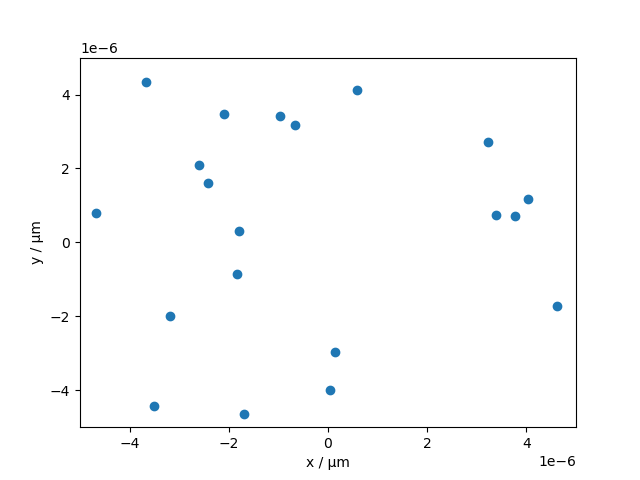

In [12]:
container_length = 5e-6 #set size of container 
number_of_particles = 20 #number of background particles 
viscosity_of_fluid = 1 #the visosity of fluid needed to compute drag on tagged particle
velocity_tagged = 0 #the velocity of the tagged particle 
velocity_background = 1e-6 #the average velocity of the bakground particle, proportional to temeprature. 
# For sake of simulation, we will assume the bacground particles to be travelling at constant velocity. 

dt = 0.01

background_particle_history = [] #position of background particles per timestep
tagged_particle_history = [] #position of tagged particle per timestep

tagged_particle_pos = np.array([container_length/2,container_length/2], dtype=float) #initialise position of tagged particle to be at the centre of the container 
tagged_particle_history.append(tagged_particle_pos) #first history point should be the initial position at t0. 

background_positions = initialise_background(
    number_of_particles=number_of_particles, 
    velocity_background=velocity_background,
    container_length=container_length
    )
background_particle_history.append(background_positions.copy())

positions_only = np.array([particle[0] for particle in background_positions])

fig,ax =plt.subplots()
ax.set_xlim(-container_length, container_length)
ax.set_ylim(-container_length, container_length)
ax.set_xlabel("x / μm")
ax.set_ylabel("y / μm")
#ax.set_aspect("equal")

background_scatter = ax.scatter(
    positions_only[:,0],
    positions_only[:,1],
    label="background particles"
)

#tagged_scatter

#ax.legend()

def animate_particles(frame):
    global background_positions
    
    background_positions = update_background_position(
        current_background=background_positions,
        container_length=container_length,
        dt=dt)
    
    positions_only = np.array([particle[0] for particle in background_positions])
    background_scatter.set_offsets(positions_only)

    return [background_scatter]

animation = FuncAnimation(
    fig,
    animate_particles,
    frames=200,
    interval=50,
    blit=False
)

plt.show()


#simulated time = frames * dt * 
#display time = frames * interval / 1000 